In [2]:
import random
import matplotlib.pyplot as plt

# Reproductibilité
random.seed(42)

# Catalogue
noms_produits_catalogue = ["Casque Bluetooth", "Smartphone", "Chargeur solaire",
                           "Robe wax", "Basket urbaine", "Sac a main",
                           "Mixeur", "Lampe LED", "Tapis",
                           "Ballon de foot", "Tapis de yoga",
                           "Creme hydratante", "Parfum"]
categories_catalogue = ["Electronique", "Electronique", "Electronique",
                        "Mode", "Mode", "Mode",
                        "Maison", "Maison", "Maison",
                        "Sport", "Sport",
                        "Beaute", "Beaute"]
prix_base_catalogue = [35000, 120000, 15000,
                     12000, 15000, 9000,
                     10000, 6000, 11000,
                     8000, 6000,
                     4000, 6500]

villes_disponibles = ["Dakar", "Abidjan", "Douala", "Brazzaville", "Lome"]
canaux_disponibles = ["Site Web", "Application", "Boutique"]
mois_disponibles = ["2026-01", "2026-02", "2026-03", "2026-04", "2026-05", "2026-06"]

# Génération des données
dates, produits, categories = [], [], []
quantites, prix_unitaires, canaux, villes = [], [], [], []

NB_VENTES = 180

for i in range(NB_VENTES):
    idx = random.randrange(len(noms_produits_catalogue))
    produit = noms_produits_catalogue[idx]
    categorie = categories_catalogue[idx]
    prix_base = prix_base_catalogue[idx]

    prix = round(random.gauss(prix_base, prix_base * 0.15))
    prix = max(prix, 0)
    quantite = random.randint(1, 5)

    if random.random() < 0.05:
        prix = 0
    if random.random() < 0.05:
        quantite = None

    mois = random.choice(mois_disponibles)
    jour = random.randint(1, 28)
    date = f"{mois}-{jour:02d}"

    dates.append(date)
    produits.append(produit)
    categories.append(categorie)
    quantites.append(quantite)
    prix_unitaires.append(prix)
    canaux.append(random.choice(canaux_disponibles))
    villes.append(random.choice(villes_disponibles))

SEUIL_PRIX_MIN = 100

print(f"{NB_VENTES} ventes générées.")
print("\nAperçu des 5 premières ventes :")
for i in range(5):
    print(f"  {i} | {dates[i]} | {produits[i]:<18} | {categories[i]:<12} "
          f"| qte={quantites[i]} | prix={prix_unitaires[i]} | {canaux[i]} | {villes[i]}")

180 ventes générées.

Aperçu des 5 premières ventes :
  0 | 2026-06-24 | Tapis de yoga      | Sport        | qte=2 | prix=7133 | Boutique | Dakar
  1 | 2026-02-17 | Ballon de foot     | Sport        | qte=4 | prix=0 | Boutique | Dakar
  2 | 2026-03-26 | Tapis              | Maison       | qte=5 | prix=11755 | Site Web | Abidjan
  3 | 2026-03-04 | Creme hydratante   | Beaute       | qte=4 | prix=4825 | Site Web | Brazzaville
  4 | 2026-05-04 | Smartphone         | Electronique | qte=3 | prix=109547 | Application | Dakar


In [2]:
def calculer_chiffre_affaires_total(quantites, prix_unitaires):
    """
    Calcule le chiffre d'affaires total.
    Ignore les ventes dont la quantite est manquante (None).
    """
    total = 0
    for i in range(len(quantites)):
        if quantites[i] is None:
            continue
        total += quantites[i] * prix_unitaires[i]
    return total


def compter_commandes_canal(canaux, canal):
    """
    Compte le nombre de commandes passées sur un canal de vente donné.
    """
    compteur = 0
    for c in canaux:
        if c == canal:
            compteur += 1
    return compteur


def quantite_totale_produit(produits, quantites, nom_produit):
    """
    Calcule la quantité totale vendue pour un produit donné.
    Ignore les quantités manquantes (None).
    """
    total = 0
    for i in range(len(produits)):
        if produits[i] == nom_produit and quantites[i] is not None:
            total += quantites[i]
    return total


def lister_produits_categorie(produits, categories, categorie):
    """
    Liste les noms uniques des produits appartenant à une catégorie donnée.
    """
    noms_uniques = []
    for i in range(len(produits)):
        if categories[i] == categorie:
            if produits[i] not in noms_uniques:
                noms_uniques.append(produits[i])
    return noms_uniques

In [3]:
def moyenne_prix_categorie(categories, prix_unitaires, categorie):
    """
    Calcule le prix moyen des produits d'une catégorie donnée.
    """
    try:
        total = 0
        compteur = 0
        for i in range(len(categories)):
            if categories[i] == categorie and prix_unitaires[i] > SEUIL_PRIX_MIN:
                total += prix_unitaires[i]
                compteur += 1
        moyenne = total / compteur
        return round(moyenne, 2)
    except ZeroDivisionError:
        print("Aucun produit trouvé pour la catégorie :", categorie)
        return None


def produit_plus_vendu(produits, quantites):
    """
    Renvoie le nom du produit avec la quantité totale vendue la plus élevée.
    """
    try:
        noms_uniques = []
        totaux = []

        for i in range(len(produits)):
            if quantites[i] is None:
                continue

            if produits[i] in noms_uniques:
                idx = noms_uniques.index(produits[i])
                totaux[idx] += quantites[i]
            else:
                noms_uniques.append(produits[i])
                totaux.append(quantites[i])

        meilleur_idx = totaux.index(max(totaux))
        return noms_uniques[meilleur_idx]
    except ValueError as e:
        print("Impossible de déterminer le produit le plus vendu :", e)
        return None


def chiffre_affaires_par_mois(dates, quantites, prix_unitaires):
    """
    Calcule le chiffre d'affaires par mois.
    Renvoie (mois_uniques, ca_mois).
    """
    mois_uniques = []
    ca_mois = []

    for i in range(len(dates)):
        mois = dates[i][:7]

        if quantites[i] is None:
            continue

        ca_vente = quantites[i] * prix_unitaires[i]

        if mois in mois_uniques:
            idx = mois_uniques.index(mois)
            ca_mois[idx] += ca_vente
        else:
            mois_uniques.append(mois)
            ca_mois.append(ca_vente)

    return mois_uniques, ca_mois


def taux_croissance_mensuel(mois_uniques, ca_mois, mois_a, mois_b):
    """
    Calcule le taux de croissance du CA (en %) entre deux mois.
    """
    try:
        idx_a = mois_uniques.index(mois_a)
        idx_b = mois_uniques.index(mois_b)
        ca_a = ca_mois[idx_a]
        ca_b = ca_mois[idx_b]

        taux = ((ca_b - ca_a) / ca_a) * 100
        return round(taux, 2)
    except ValueError:
        print("Un des deux mois demandés n'existe pas dans les données.")
        return None
    except ZeroDivisionError:
        print("Impossible de calculer : le CA du mois de référence est nul.")
        return None

In [4]:
def tester(nom, fonction):
    try:
        resultat = fonction()
        if resultat is None or resultat == 0 or resultat == [] or resultat == ([], []):
            print(f"EN ATTENTE - {nom} : pas encore implémentée")
        else:
            print(f"OK - {nom} : {resultat}")
    except Exception as e:
        print(f"ERREUR - {nom} : {e}")

print("--- Niveau Débutant ---")
tester("CA total", lambda: calculer_chiffre_affaires_total(quantites, prix_unitaires))
tester("Canal Site Web", lambda: compter_commandes_canal(canaux, "Site Web"))
tester("Qté Smartphone", lambda: quantite_totale_produit(produits, quantites, "Smartphone"))
tester("Produits Mode", lambda: lister_produits_categorie(produits, categories, "Mode"))

print("\n--- Niveau Intermédiaire ---")
tester("Moyenne prix Mode", lambda: moyenne_prix_categorie(categories, prix_unitaires, "Mode"))
tester("Produit plus vendu", lambda: produit_plus_vendu(produits, quantites))

mois_u, ca_m = chiffre_affaires_par_mois(dates, quantites, prix_unitaires)
tester("CA par mois", lambda: (mois_u, ca_m))
tester("Croissance janv-fev", lambda: taux_croissance_mensuel(mois_u, ca_m, "2026-01", "2026-02"))

--- Niveau Débutant ---
OK - CA total : 10190132
OK - Canal Site Web : 56
OK - Qté Smartphone : 36
OK - Produits Mode : ['Basket urbaine', 'Robe wax', 'Sac a main']

--- Niveau Intermédiaire ---
OK - Moyenne prix Mode : 13239.9
OK - Produit plus vendu : Basket urbaine
OK - CA par mois : (['2026-06', '2026-02', '2026-03', '2026-05', '2026-04', '2026-01'], [1980495, 1548891, 1284038, 1437370, 1525474, 2413864])
OK - Croissance janv-fev : -35.83


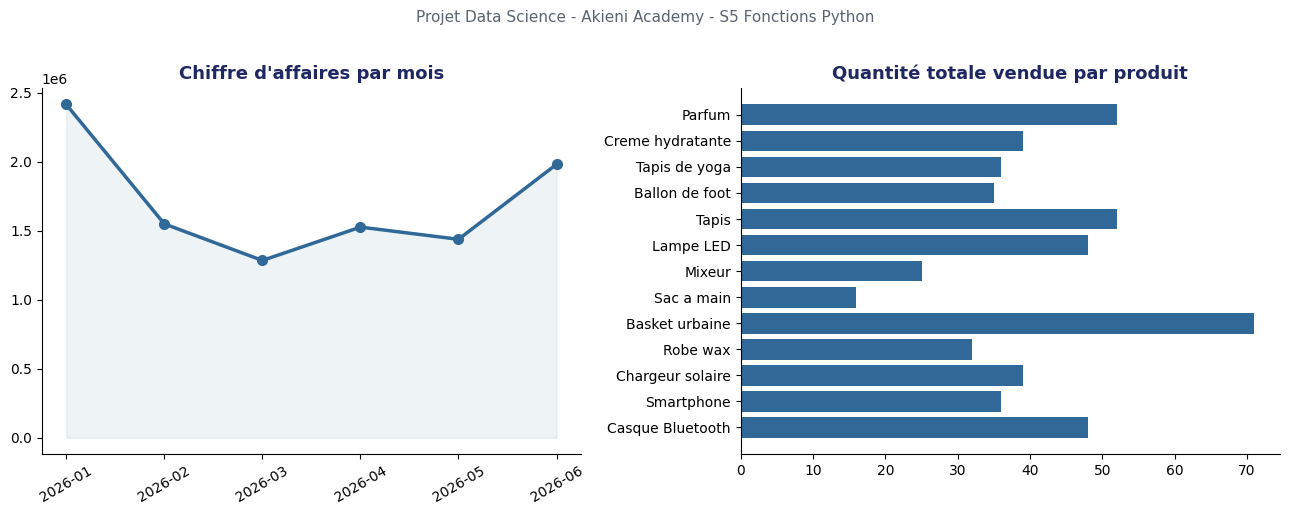

In [5]:
NAVY = "#1E2761"
BLUE = "#306998"
YELLOW = "#FFD43B"

plt.rcParams["font.family"] = "DejaVu Sans"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

# Graphique 1 : CA par mois
ax = axes[0]
try:
    mois_uniques, ca_mois = chiffre_affaires_par_mois(dates, quantites, prix_unitaires)
    if not mois_uniques:
        raise ValueError("liste vide")
    paires_triees = sorted(zip(mois_uniques, ca_mois))
    mois_tries = [p[0] for p in paires_triees]
    ca_tries = [p[1] for p in paires_triees]
    ax.plot(mois_tries, ca_tries, marker="o", color=BLUE, linewidth=2.5, markersize=7)
    ax.fill_between(mois_tries, ca_tries, color=BLUE, alpha=0.08)
    ax.set_title("Chiffre d'affaires par mois", fontsize=13, fontweight="bold", color=NAVY)
    ax.tick_params(axis="x", rotation=30)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
except Exception:
    ax.text(0.5, 0.5, "Terminez chiffre_affaires_par_mois()\npour débloquer ce graphique",
            ha="center", va="center", fontsize=12, color=NAVY, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])

# Graphique 2 : Quantité par produit
ax = axes[1]
try:
    totaux_catalogue = [quantite_totale_produit(produits, quantites, nom)
                        for nom in noms_produits_catalogue]
    if sum(totaux_catalogue) == 0:
        raise ValueError("aucune quantité calculée")
    ax.barh(noms_produits_catalogue, totaux_catalogue, color=BLUE)
    ax.set_title("Quantité totale vendue par produit", fontsize=13, fontweight="bold", color=NAVY)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
except Exception:
    ax.text(0.5, 0.5, "Terminez quantite_totale_produit()\npour débloquer ce graphique",
            ha="center", va="center", fontsize=12, color=NAVY, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Projet Data Science - Akieni Academy - S5 Fonctions Python",
             fontsize=11, color="#5B6572", y=1.02)
plt.tight_layout()
plt.savefig("mon_graphique_ventes.png", dpi=150, bbox_inches="tight")
plt.show()

- 1. Le produit le plus vendu est la "Basket urbaine".

In [7]:
# ============================================================
# SYNTHÈSE - Réponds en 3-4 phrases
# ============================================================

print("=== SYNTHÈSE ===")

# Question 1 : Produit le plus vendu
produit_top = produit_plus_vendu(produits, quantites)
print(f"1. Produit le plus vendu : {produit_top}")

# Question 2 : Évolution CA
mois_u, ca_m = chiffre_affaires_par_mois(dates, quantites, prix_unitaires)
croissance = taux_croissance_mensuel(mois_u, ca_m, "2026-01", "2026-02")
print(f"2. Taux de croissance janv-fév : {croissance}%")

# Question 3 : Données manquantes
nb_erreurs = sum(1 for q in quantites if q is None) + sum(1 for p in prix_unitaires if p == 0)
print(f"3. Données erronées détectées : {nb_erreurs}")

print("\n--- Les details sont en bas ---")

=== SYNTHÈSE ===
1. Produit le plus vendu : Basket urbaine
2. Taux de croissance janv-fév : -35.83%
3. Données erronées détectées : 7

--- Les details sont en bas ---


- 1. Le produit le plus vendu est la "Basket urbaine".
- 2. Le chiffre d'affaires a enregistré une baisse significative de -35.83% entre janvier et février 2026 et  une augmentation entre Mars et juin 2026.
- 3. Un total de 7 données erronées ont été détectées (quantité manquante ou prix à zéro). Les fonctions ont géré ces cas robustement en les ignorant via des conditions (`if quantites[i] is None: continue`) et en utilisant des blocs `try-except` pour prévenir les erreurs, assurant ainsi la continuité de l'exécution.
- 4. La fonction `produit_plus_vendu` a été la plus difficile à écrire car elle impliquait de gérer l'agrégation des quantités pour des produits uniques en maintenant des listes parallèles et de déterminer le maximum à partir de ces données.